In [1]:
# 1. Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Physics Problem:
Imagine one now needs to predict whether an object will slide down an inclined plane based on its physical properties. This binary classification problem (slide/not slide) can be modeled using linear decision boundaries.


In [2]:
# 2. Generate Synthetic Physics Data
np.random.seed(42)

# Physical parameters
n_samples = 600
g = 9.81  # gravitational acceleration (m/s²)

# Features: [mass (kg), angle (radians), friction coefficient]
X = np.column_stack([
    np.random.uniform(0.1, 10, n_samples),        # Mass
    np.random.uniform(0, np.pi/3, n_samples),    # Angle (0-60 degrees)
    np.random.uniform(0.1, 0.8, n_samples)       # Friction coefficient
])

# Physics-based labeling: slide if mg sinθ > μmg cosθ → tanθ > μ
y = (np.tan(X[:,1]) > X[:,2]).astype(int)  # 1=Slide, 0=Static

# Add realistic measurement noise
X += np.random.normal(0, 0.1, X.shape)

# Data Preprocessing

In [3]:
# 3. Split and Standardize Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training

In [4]:
# 4. Create and Train Classifier
physics_clf = LogisticRegression().fit(X_train_scaled, y_train)

# Model Evaluation

In [5]:
# 5. Performance Analysis
train_pred = physics_clf.predict(X_train_scaled)
test_pred = physics_clf.predict(X_test_scaled)

print(f"Training Accuracy: {accuracy_score(y_train, train_pred):.2f}")
print(f"Test Accuracy: {accuracy_score(y_test, test_pred):.2f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, test_pred))

Training Accuracy: 0.92
Test Accuracy: 0.91

Confusion Matrix:
[[ 58   5]
 [ 11 106]]


# Physics Interpretation

In [6]:
# 6. Analyze Model Coefficients
features = ['Mass', 'Angle', 'Friction']
coefs = physics_clf.coef_[0]

print("Feature Contributions:")
for f, c in zip(features, coefs):
    print(f"{f}: {c:.2f}")

Feature Contributions:
Mass: 0.11
Angle: 3.75
Friction: -1.90


Predict whether a 5 kg object will slide on a 30 degrees incline with $\mu=0.4$.

In [7]:
# New Prediction
new_sample = np.array([[5, np.radians(30), 0.4]])
new_sample_scaled = scaler.transform(new_sample)

prediction = physics_clf.predict(new_sample_scaled)
print("\nPrediction:", "Will slide" if prediction[0] else "Will stay")


Prediction: Will slide


# Physical verification: 
Calculate $\tan(30^{\circ})\approx 0.577 >0.4$, so it should slide

In [8]:
# Verify Data Shapes
print("Training data shape:", X_train_scaled.shape)  # Should be (n,3)
print("Test data shape:", X_test_scaled.shape)       # Should be (m,3)

Training data shape: (420, 3)
Test data shape: (180, 3)


# Visualization (2D Projection)

In [9]:
# 7. Visualize Decision Boundary (Angle vs Friction)
def plot_decision_boundary():
    plt.figure(figsize=(10,6))
    
    # Create grid for 2 most important features
    angle_vals = np.linspace(X[:,1].min(), X[:,1].max(), 100)
    friction_vals = np.linspace(X[:,2].min(), X[:,2].max(), 100)
    xx, yy = np.meshgrid(angle_vals, friction_vals)
    
    # Maintain original 3-feature structure with mass=mean_value
    mass_fixed = np.full(xx.ravel().shape, X[:,0].mean())
    grid = np.c_[mass_fixed, xx.ravel(), yy.ravel()]
    
    # Apply same scaling
    grid_scaled = scaler.transform(grid)
    
    # Predict and plot
    Z = physics_clf.predict(grid_scaled)
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
    plt.scatter(X[:,1], X[:,2], c=y, cmap='bwr')
    plt.xlabel("Angle (radians)")
    plt.ylabel("Friction Coefficient")
    plt.title("Corrected Decision Boundary")

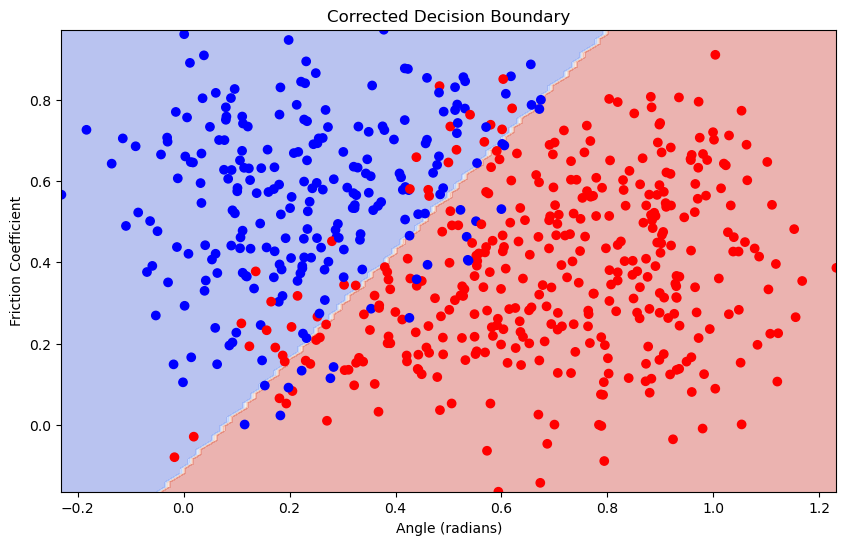

In [10]:
plot_decision_boundary()